
# Store Trial Analysis: New Layout Impact on Chip Sales

### Business Context
Any operational change — a new store layout, a pricing test, a promotional mechanic — is expensive to roll out across an entire retail network, and doing so blind risks getting it wrong at scale. Retailers typically pilot a change in a small number of stores before committing to a full rollout. Because store selection for the trial wasn't randomized, a simple before/after or trial-vs-average comparison can't isolate the effect of the layout from ordinary store-to-store variation — the analysis needs a constructed counterfactual instead.

### Business Challenge
Did the new store layout trial (Stores 77, 86, 88, February–April 2019) produce a genuine, statistically defensible increase in chip sales, or does the observed change fall within normal store-to-store variability? The Category Manager needs a data-driven recommendation on whether to roll the layout out to all stores.

### Approach
1. Select control stores that closely match each trial store's pre-trial behavior
2. Compare trial store performance against its matched control during the trial period
3. Use confidence intervals to test whether the difference is statistically significant
4. Identify possible drivers behind any change in sales

In [37]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set(color_codes=True)

df = pd.read_csv('data/processed/QVI_data.csv')
print(df.dtypes)
df['DATE'] = pd.to_datetime(df['DATE'])
print('\nUpdated data types:', df.dtypes)

print(df.shape)

DATE                 object
STORE_NBR             int64
LYLTY_CARD_NBR        int64
TXN_ID                int64
PROD_NBR              int64
PROD_NAME            object
PROD_QTY              int64
TOT_SALES           float64
PACK_SIZE             int64
BRAND                object
LIFESTAGE            object
PREMIUM_CUSTOMER     object
dtype: object

Updated data types: DATE                datetime64[ns]
STORE_NBR                    int64
LYLTY_CARD_NBR               int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                   object
PROD_QTY                     int64
TOT_SALES                  float64
PACK_SIZE                    int64
BRAND                       object
LIFESTAGE                   object
PREMIUM_CUSTOMER            object
dtype: object
(248230, 12)


In [38]:
print(df.columns)


Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='object')


## Monthly Analysis
Store performance summarized into monthly data for clearer analysis.
- Sales revenue per month
- Number of unique customers per month
- Average transactions per customer per month
Monthly data will be used to identify which stores behaved similarly to the trial stores before the trial.

In [39]:
# Break down of monthly sales of each store (Sales rev, number of customers, avg transactions per customer)
df['YEARMONTH'] = df['DATE'].dt.to_period('M')
monthly = df.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    {'TOT_SALES': 'sum', 'LYLTY_CARD_NBR': 'nunique','TXN_ID': 'nunique'}
).reset_index()
monthly['AVG_TRANSACTION_PER_CUSTOMER'] = monthly['TXN_ID'] / monthly['LYLTY_CARD_NBR']
print(monthly.head())
print()
monthly.columns = ['Store_num', 'YearMonth', 'Total_Sales','Num_Customers', 'Number of Transactions','Avg_Transaction_Per_Customer']
print(monthly.head())
print(monthly['YearMonth'].unique())

   STORE_NBR YEARMONTH  TOT_SALES  LYLTY_CARD_NBR  TXN_ID  \
0          1   2018-07      191.6              48      50   
1          1   2018-08      168.4              41      41   
2          1   2018-09      268.1              57      59   
3          1   2018-10      178.0              40      41   
4          1   2018-11      187.5              45      46   

   AVG_TRANSACTION_PER_CUSTOMER  
0                      1.041667  
1                      1.000000  
2                      1.035088  
3                      1.025000  
4                      1.022222  

   Store_num YearMonth  Total_Sales  Num_Customers  Number of Transactions  \
0          1   2018-07        191.6             48                      50   
1          1   2018-08        168.4             41                      41   
2          1   2018-09        268.1             57                      59   
3          1   2018-10        178.0             40                      41   
4          1   2018-11        187.5   

In [40]:
# Create measure to compare the different control stores to the trial stores
trial_stores = [77, 86, 88]
print(monthly[monthly['Store_num'].isin(trial_stores)][['Store_num', 'YearMonth', 'Total_Sales']])
print()



      Store_num YearMonth  Total_Sales
880          77   2018-07       273.80
881          77   2018-08       252.90
882          77   2018-09       219.60
883          77   2018-10       194.30
884          77   2018-11       224.90
885          77   2018-12       255.40
886          77   2019-01       201.40
887          77   2019-02       222.20
888          77   2019-03       255.10
889          77   2019-04       263.50
890          77   2019-05       272.30
891          77   2019-06       238.90
977          86   2018-07       856.20
978          86   2018-08       732.45
979          86   2018-09       855.20
980          86   2018-10       909.40
981          86   2018-11       856.60
982          86   2018-12       817.60
983          86   2019-01       800.60
984          86   2019-02       888.80
985          86   2019-03       961.20
986          86   2019-04       809.20
987          86   2019-05       835.00
988          86   2019-06       776.60
1001         88   2018-07

### Control Store Selection
Need to find control stores that closely match each trial store (77, 86, 88) in terms of the pre-trial behavior. Pre trial period consists of July 2019 to January 2019.

In [41]:
#Pre trial period
pre_trial = monthly[monthly['YearMonth'] < '2019-02']
sales_pivot = pre_trial.pivot(index='YearMonth', columns='Store_num', values='Total_Sales')
print(sales_pivot.head())
print(sales_pivot.shape)

Store_num    1      2        3       4      5      6       7      8      9    \
YearMonth                                                                      
2018-07    191.6  140.5  1164.90  1318.3  774.4  244.6  1004.3  361.2  276.3   
2018-08    168.4  183.5   998.15  1188.1  670.5  180.2  1058.7  362.6  323.4   
2018-09    268.1  136.5  1011.30  1168.0  859.8  197.5  1096.3  282.8  346.1   
2018-10    178.0  160.1  1017.50  1275.0  756.2  268.9   972.1  412.6  333.6   
2018-11    187.5  146.0   936.60  1089.6  707.0  250.1  1025.5  328.8  341.1   

Store_num     10   ...   263    264    265    266   267     268     269  \
YearMonth          ...                                                    
2018-07    850.20  ...  38.7  206.9  231.9  124.7   6.2  218.90   935.0   
2018-08    860.35  ...  26.5  190.5  210.1  135.0  24.9  291.95   801.3   
2018-09    867.20  ...  21.8  183.7  126.9  136.0  23.3  153.80   833.6   
2018-10    817.60  ...  31.4  167.4  150.0  162.7  14.4  227.30 

### Pearson Correlation
Pearson Correlation was implemented to calculate how closely each store's monthly sales pattern correlates with each trial store. A correlation closer to 1 would suggest stores behave similarly over time. 

In [42]:
# Pearson correlation of the trial stores with the control stores to see which control store is most similar to the trial stores in the pre-trial period

# Drop stores with missing months
sales_pivot_clean = sales_pivot.dropna(axis=1)


for store in trial_stores:
    correlations = sales_pivot_clean.corrwith(sales_pivot_clean[store])
    correlations = correlations.drop(store)
    correlations = correlations.dropna() 
    correlations = correlations[correlations < 1.0]
    correlations = correlations.sort_values(ascending=False)
    print(f'\nTop 5 control store candidates for Store {store}:')
    print(round(correlations.head(),3))


Top 5 control store candidates for Store 77:
Store_num
233    0.965
50     0.902
71     0.858
119    0.839
162    0.796
dtype: float64

Top 5 control store candidates for Store 86:
Store_num
260    0.851
155    0.825
6      0.814
132    0.785
114    0.781
dtype: float64

Top 5 control store candidates for Store 88:
Store_num
91     0.912
159    0.911
204    0.880
1      0.846
240    0.817
dtype: float64


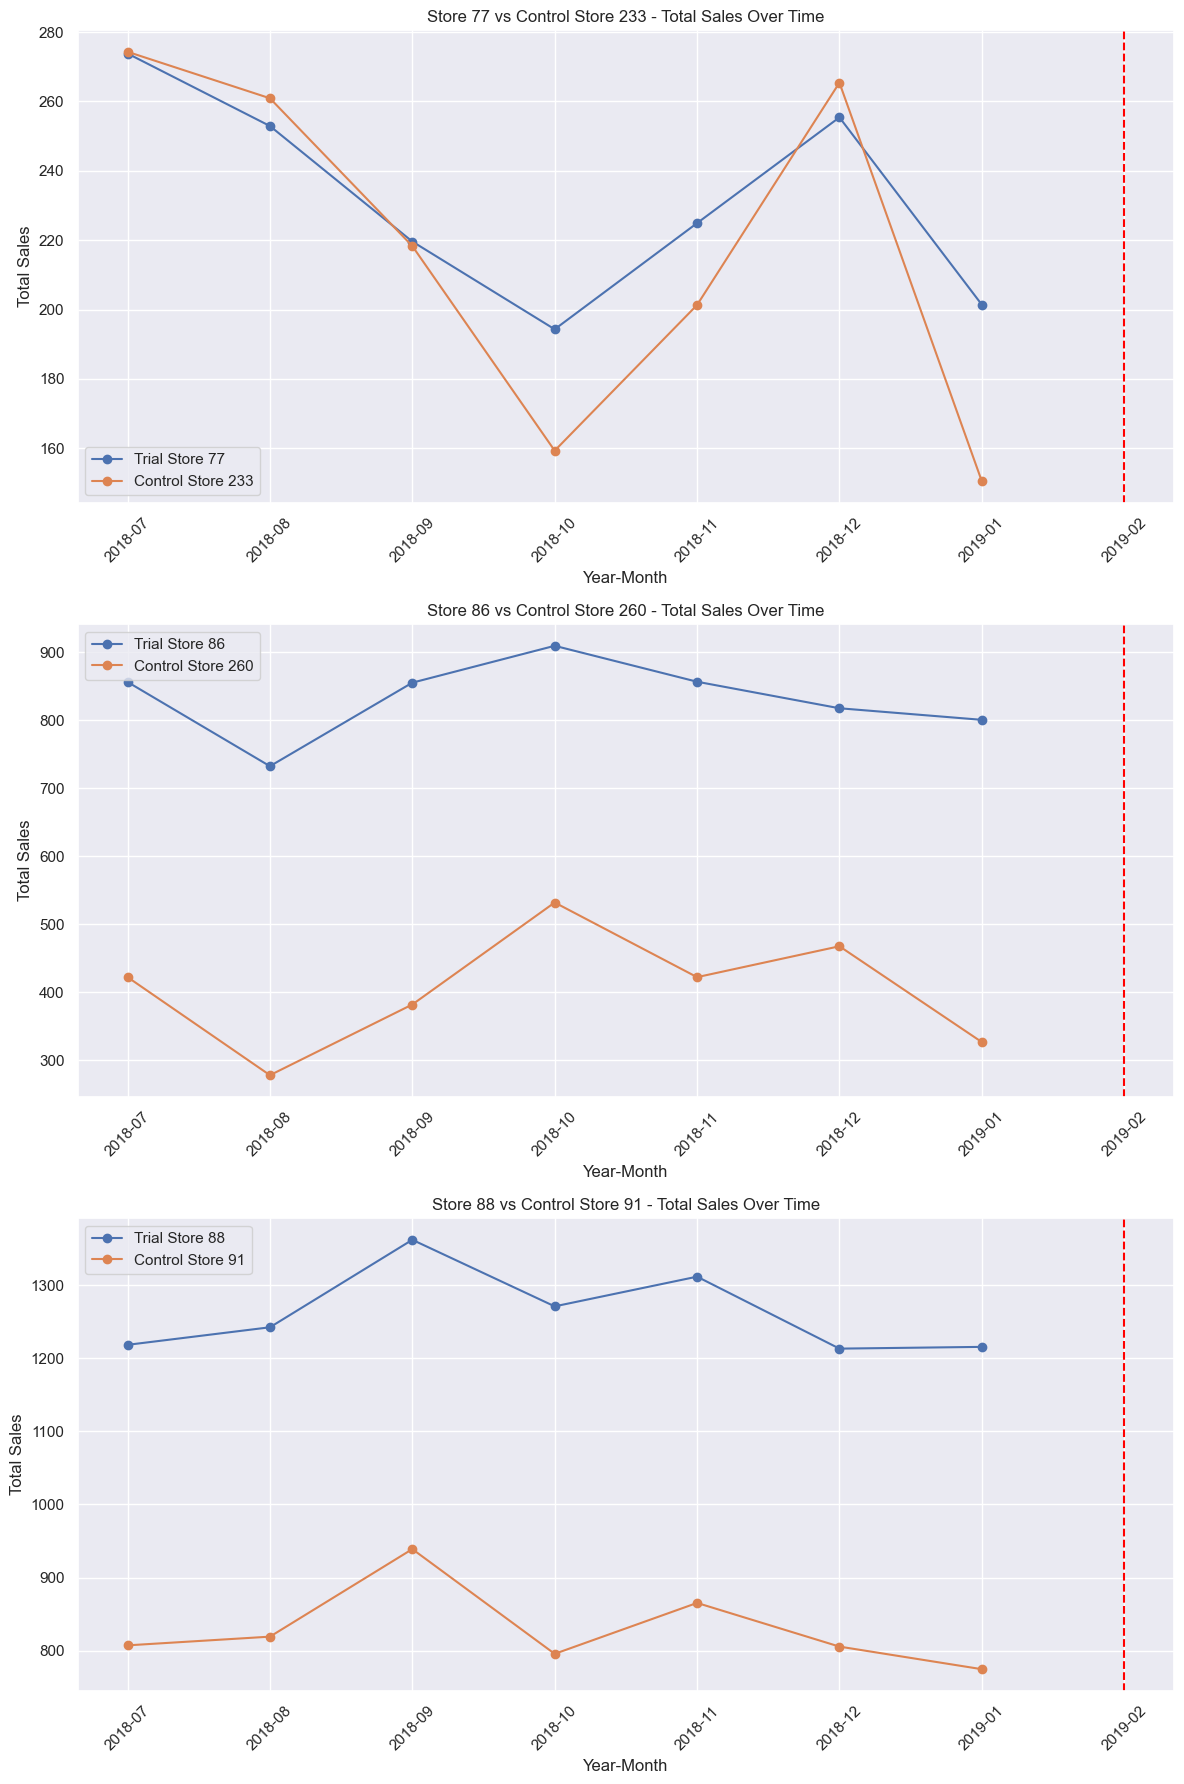

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
control_pairs = [(77, 233), (86, 260), (88, 91)]
for i, (trial_store, control_store) in enumerate(control_pairs):
    trial_data = sales_pivot[trial_store]
    control_data = sales_pivot[control_store]
    
    axes[i].plot(trial_data.index.astype(str), trial_data.values, label=f'Trial Store {trial_store}', marker='o')
    axes[i].plot(control_data.index.astype(str), control_data.values, label=f'Control Store {control_store}', marker='o')
    
    axes[i].set_title(f'Store {trial_store} vs Control Store {control_store} - Total Sales Over Time')
    axes[i].set_xlabel('Year-Month')
    axes[i].set_ylabel('Total Sales')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axvline(x='2019-02', color='red', linestyle='--', label='Trial Start')

plt.tight_layout()
plt.show()
 

### Visible Issue
Although the Pearson Correlation provides the best match in terms of sales trend, the plots show differences in sales volume, specifically for stores 86 and 88. To further improve control over the appropriate store, a size filter was added to account for the possibility that the size of the store plays a role in sales volume. 


In [44]:
pre_trial_avg = sales_pivot_clean.mean()

for store in [77, 86, 88]:
    avg = pre_trial_avg[store]
    similar_size = pre_trial_avg[
        (pre_trial_avg >= avg * 0.8) & 
        (pre_trial_avg <= avg * 1.2)
    ].index.tolist()
    
    # Remove the trial store itself
    similar_size = [s for s in similar_size if s != store]
    
    # Correlation within similar sized stores only
    correlations = sales_pivot_clean[similar_size].corrwith(sales_pivot_clean[store])
    correlations = correlations[correlations < 1.0].dropna()
    correlations = correlations.sort_values(ascending=False)
    print(f'\nTop 5 control candidates for Store {store} (size + correlation):')
    print(round(correlations.head(),3))


Top 5 control candidates for Store 77 (size + correlation):
Store_num
233    0.965
50     0.902
53     0.551
188    0.462
265    0.432
dtype: float64

Top 5 control candidates for Store 86 (size + correlation):
Store_num
155    0.825
114    0.781
56     0.780
269    0.768
222    0.761
dtype: float64

Top 5 control candidates for Store 88 (size + correlation):
Store_num
201    0.484
125    0.453
217    0.421
123    0.402
75     0.365
dtype: float64


### Final Control Store Pairs

**Store 77 → Control Store 233**
Store 233 had the highest correlation among size-matched candidates (0.965), confirming it as the strongest pre-trial behavioral match for Store 77.

**Store 86 → Control Store 155**
Store 155 had the highest correlation among size-matched candidates (0.825), confirming it as the strongest pre-trial behavioral match for Store 86.

**Store 88 → Control Store 201**
Store 201 emerged as the highest-correlation match within this size band (0.481) and is used as the control for Store 88.

The charts below confirm that each pair tracked closely in the pre-trial period, validating the control store selections.

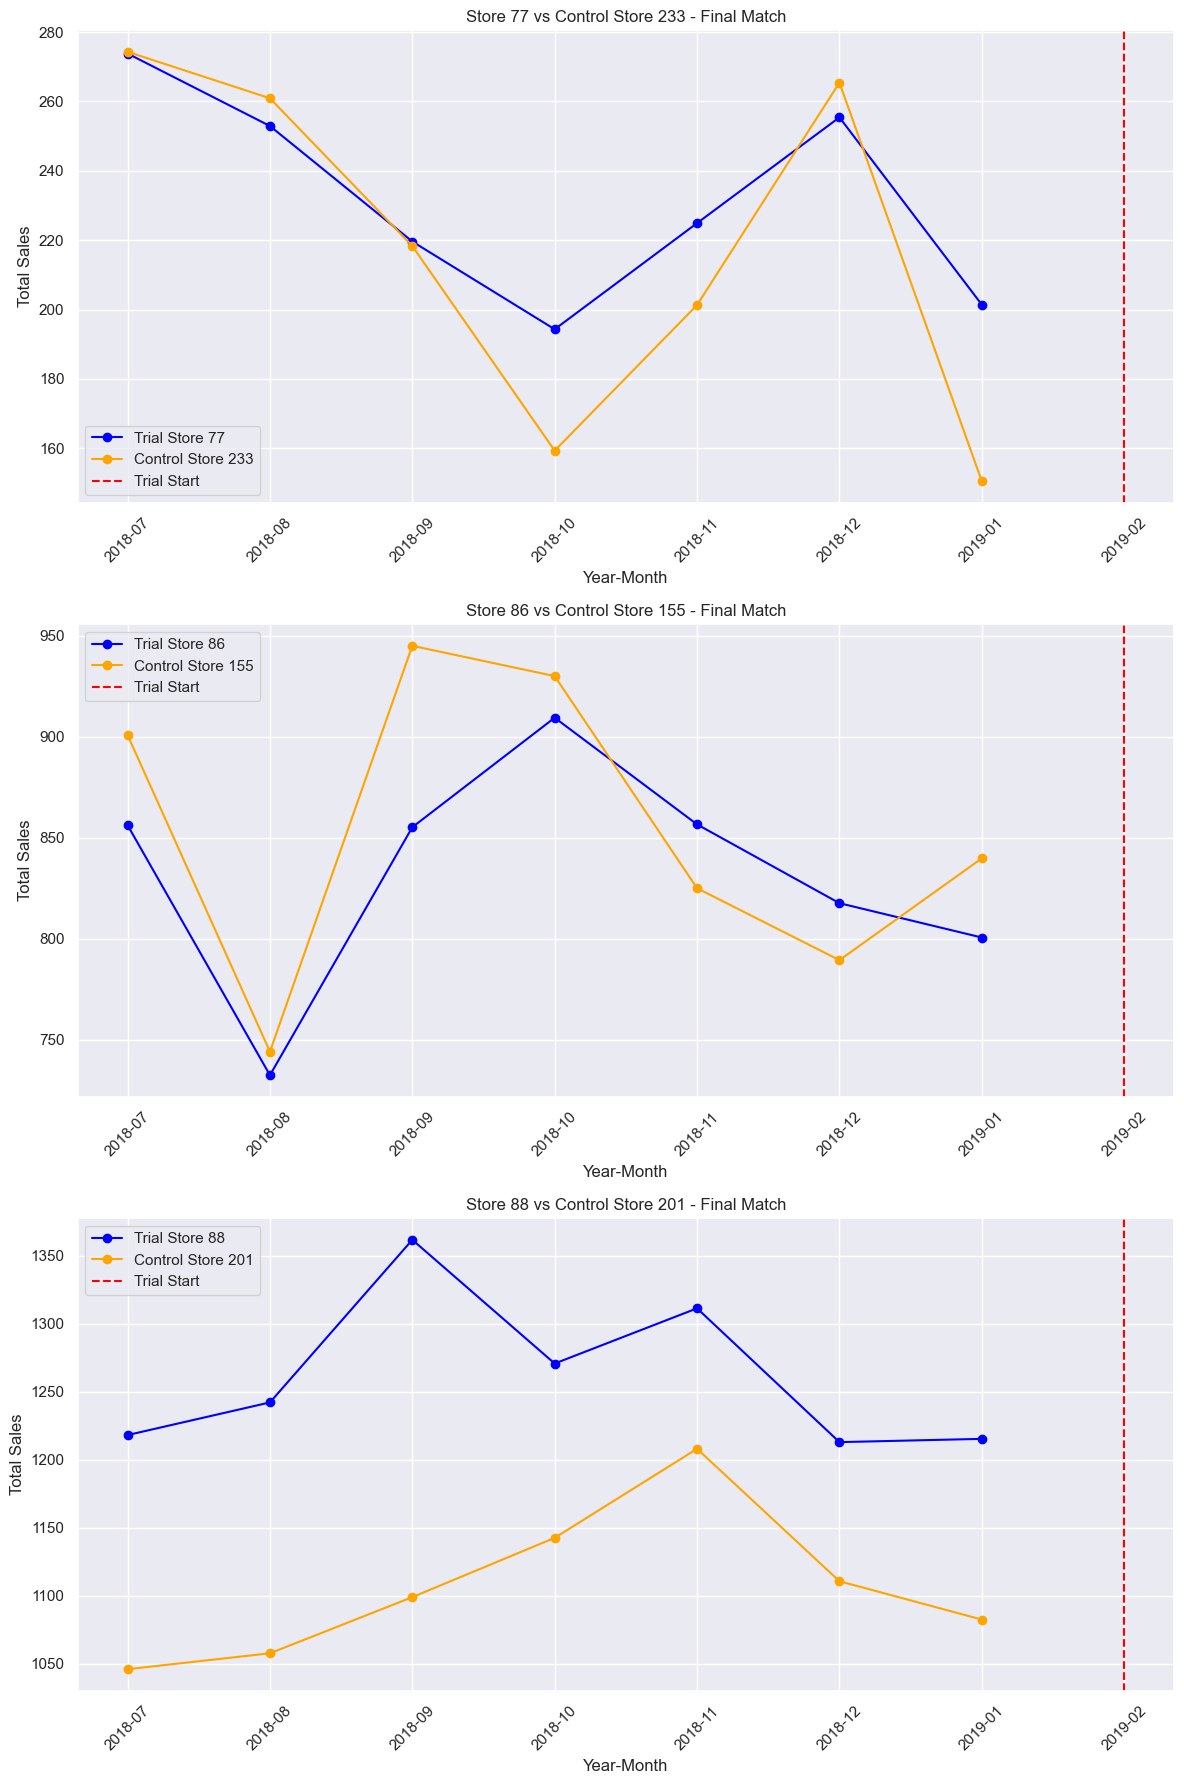

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
control_pairs = [(77, 233), (86, 155), (88, 201)]

for i, (trial_store, control_store) in enumerate(control_pairs):
    trial_data = sales_pivot[trial_store]
    control_data = sales_pivot[control_store]
    
    axes[i].plot(trial_data.index.astype(str), trial_data.values, 
                 label=f'Trial Store {trial_store}', marker='o', color='blue')
    axes[i].plot(control_data.index.astype(str), control_data.values, 
                 label=f'Control Store {control_store}', marker='o', color= 'orange')
    axes[i].axvline(x='2019-02', color='red', linestyle='--', label='Trial Start')
    axes[i].set_title(f'Store {trial_store} vs Control Store {control_store} - Final Match')
    axes[i].set_xlabel('Year-Month')
    axes[i].set_ylabel('Total Sales')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Trial Assessment

Now we compare each trial store against its matched control store during the trial period (February to April 2019).

The control store sales are scaled to match the trial store's pre-trial baseline — this removes any remaining size difference  between the two stores so that any gap during the trial reflects the layout change rather than pre-existing differences.

A 95% confidence interval is built from the natural variation between the two stores in the pre-trial period. If the trial store's sales fall outside this band during the trial months, the difference is statistically significant.

In [46]:
# Trial Assessment
trial_period = ['2019-02', '2019-03', '2019-04']
pre_trial_period =['2018-07', '2018-08', '2018-09', 
                    '2018-10', '2018-11', '2018-12', '2019-01']


t_crit = stats.t.ppf(0.975, df=len(pre_trial_period)-1)  # two-tailed t-test critical value


for trial_store, control_store in control_pairs:
    trial_sales = monthly[monthly['Store_num'] == trial_store].set_index('YearMonth')['Total_Sales']
    control_sales = monthly[monthly['Store_num'] == control_store].set_index('YearMonth')['Total_Sales']

    scaling_factor = trial_sales[pre_trial_period].sum() / control_sales[pre_trial_period].sum()
    scaled_control = control_sales * scaling_factor
    
    pct_diff = (trial_sales - scaled_control) / scaled_control
    std_dev = pct_diff[pre_trial_period].std()
    
    upper = scaled_control * (1 + std_dev * t_crit)
    lower = scaled_control * (1 - std_dev * t_crit)

    print(f'\nStore {trial_store} vs Control {control_store}')
    print('Trial period % difference:')
    print(pct_diff[trial_period])
    print(f'Std dev (pre-trial): {std_dev:.4f}')
    print(f't-critical (df={len(pre_trial_period)-1}): {t_crit:.4f}')
    print('Trial store outside 95% CI:')
    print((trial_sales[trial_period] > upper[trial_period]) | 
          (trial_sales[trial_period] < lower[trial_period]))



Store 77 vs Control 233
Trial period % difference:
YearMonth
2019-02   -0.083699
2019-03    0.351608
2019-04    0.723358
Freq: M, Name: Total_Sales, dtype: float64
Std dev (pre-trial): 0.1364
t-critical (df=6): 2.4469
Trial store outside 95% CI:
YearMonth
2019-02    False
2019-03     True
2019-04     True
Freq: M, Name: Total_Sales, dtype: bool

Store 86 vs Control 155
Trial period % difference:
YearMonth
2019-02    0.051077
2019-03    0.258671
2019-04    0.029641
Freq: M, Name: Total_Sales, dtype: float64
Std dev (pre-trial): 0.0490
t-critical (df=6): 2.4469
Trial store outside 95% CI:
YearMonth
2019-02    False
2019-03     True
2019-04    False
Freq: M, Name: Total_Sales, dtype: bool

Store 88 vs Control 201
Trial period % difference:
YearMonth
2019-02    0.167161
2019-03   -0.031541
2019-04   -0.042093
Freq: M, Name: Total_Sales, dtype: float64
Std dev (pre-trial): 0.0479
t-critical (df=6): 2.4469
Trial store outside 95% CI:
YearMonth
2019-02     True
2019-03    False
2019-04    Fa

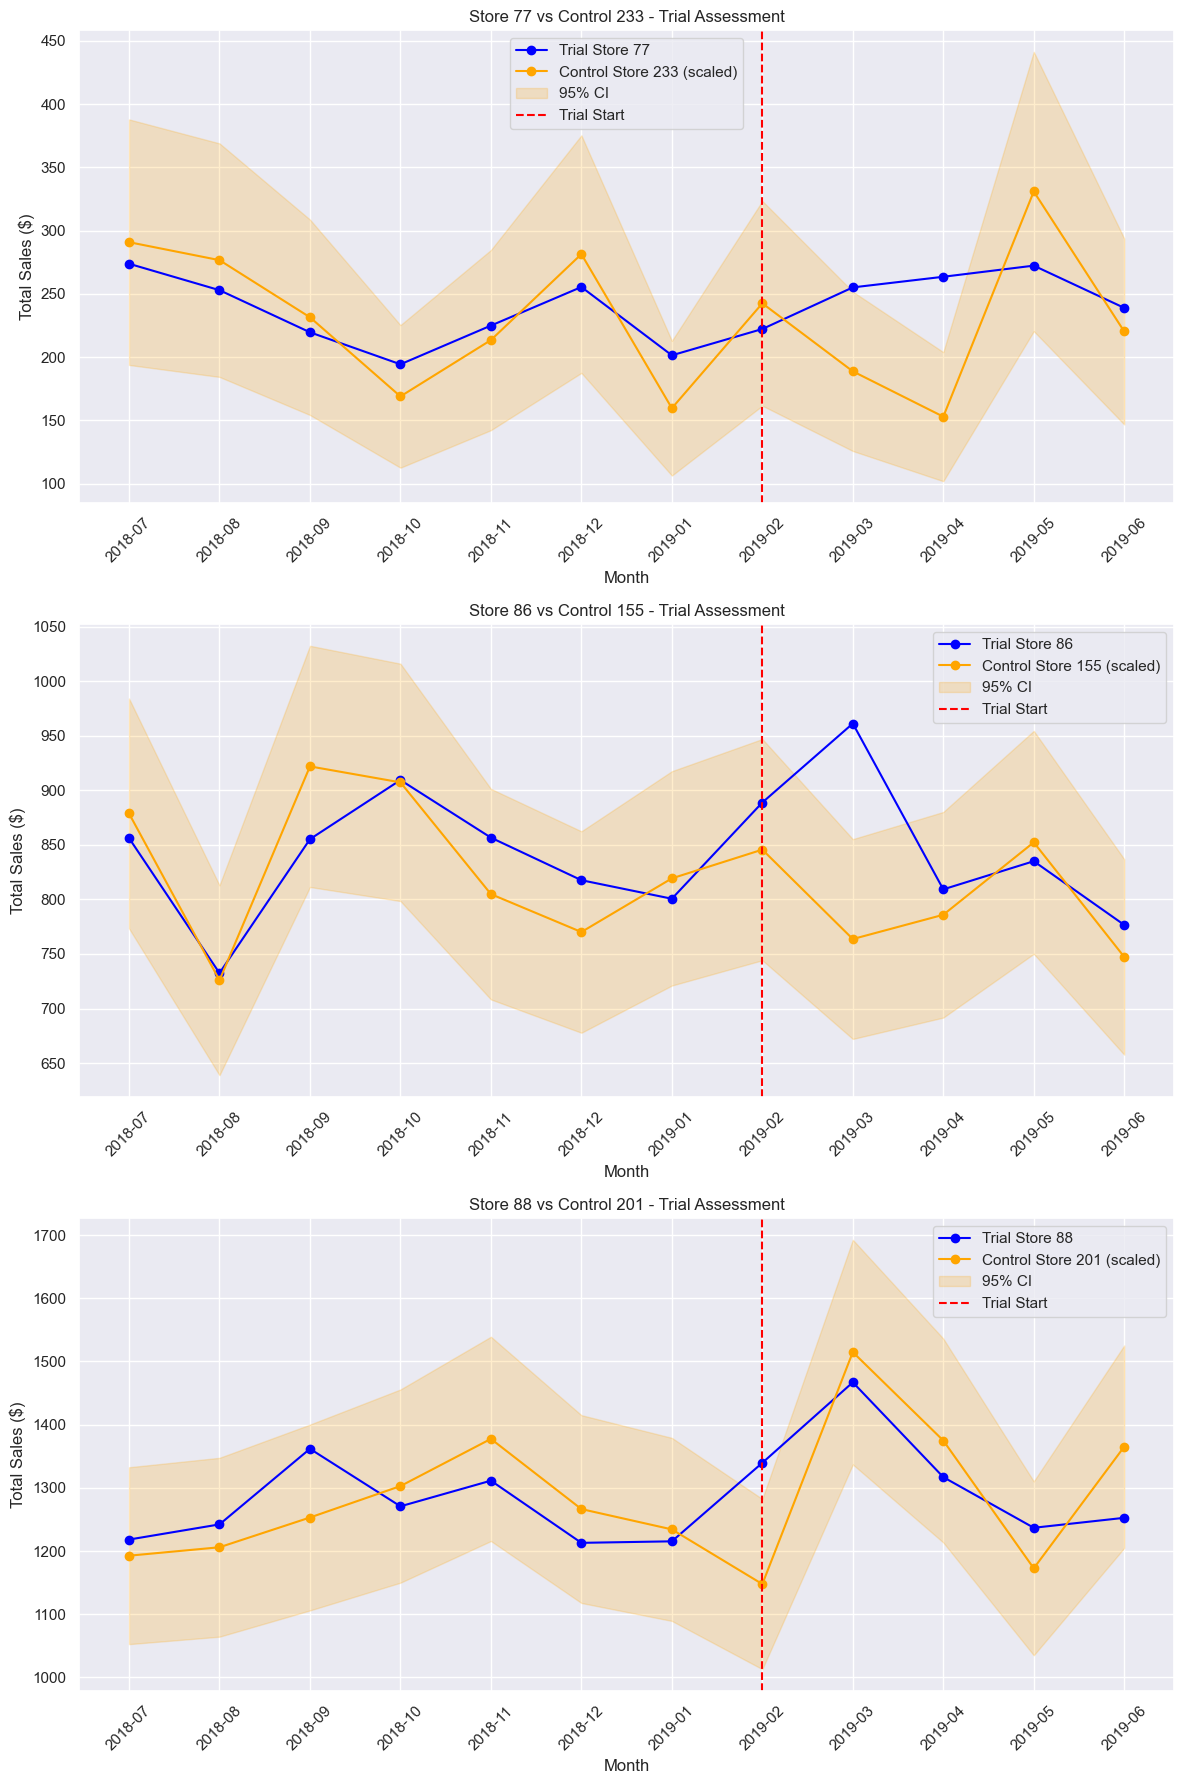

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for i, (trial_store, control_store) in enumerate(control_pairs):
    trial_sales = monthly[monthly['Store_num'] == trial_store].set_index('YearMonth')['Total_Sales']
    control_sales = monthly[monthly['Store_num'] == control_store].set_index('YearMonth')['Total_Sales']
    
    scaling_factor = trial_sales[pre_trial_period].sum() / control_sales[pre_trial_period].sum()
    scaled_control = control_sales * scaling_factor
    
    pct_diff = (trial_sales - scaled_control) / scaled_control
    std_dev = pct_diff[pre_trial_period].std()

    upper = scaled_control * (1 + std_dev * t_crit)
    lower = scaled_control * (1 - std_dev * t_crit)

    months = trial_sales.index.astype(str)
    
    axes[i].plot(months, trial_sales.values, label=f'Trial Store {trial_store}', marker='o', color='blue')
    axes[i].plot(months, scaled_control.values, label=f'Control Store {control_store} (scaled)', marker='o', color='orange')
    axes[i].fill_between(months, lower.values, upper.values, alpha=0.2, color='orange', label='95% CI')
    axes[i].axvline(x='2019-02', color='red', linestyle='--', label='Trial Start')
    axes[i].set_title(f'Store {trial_store} vs Control {control_store} - Trial Assessment')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Total Sales ($)')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Trial Assessment — Results

The orange shaded band represents a 95% confidence interval built from each store pair's pre-trial variation (using a t-distribution critical value, appropriate for the 7-month sample size). Sales inside the band fall within normal variation between the trial and control store; sales outside the band indicate a difference too large to attribute to chance.

**Store 77 — Significant, sustained uplift.** Sales dipped 8.4% below control in February, then reversed sharply — breaking above the confidence band in both March (+35.2%) and April (+72.3%). The early dip rules out a simple "instant boost" story; the layout took a month to gain traction before producing a clear, statistically confirmed, and accelerating uplift.

**Store 86 — A real but short-lived spike.** Sales broke above the band in March (+25.9%) but fell back within normal range by April (+3.0%). The March lift was statistically genuine, not noise, but it didn't persist — consistent with a novelty effect that faded rather than a durable shift in customer behavior.

**Store 88 — No attributable effect.** The test did raise one flag — February, when the gap between Store 88 and its control hit +16.7%. But a flag only means the gap was unusually big, not that Store 88 improved. Looking closer, the gap came from the control store having one bad month, not from Store 88 selling more: Store 88's customer count and spend per customer were completely normal that month, and by March both stores were moving together again. One isolated flag, caused by the control store and backed up by nothing else, isn't evidence the layout did anything. One caveat: Store 88's control was the weakest match of the three pairs (r = 0.48 vs 0.97 and 0.83), so this reads as "no effect found," not "proof there was no effect."

### Driver Analysis

Having confirmed that the trial had a statistically significant effect on sales in Stores 77 and 86, we now investigate what drove those differences.
Two possible drivers:
- More customers visiting the store
- Existing customers buying more chips per visit

Understanding the driver matters because it changes the recommendation — attracting new customers vs influencing 
existing buying behavior require different strategies.

In [48]:
# Customer count and avg transactions per customer assessment throughout the trial period
for trial_store, control_store in control_pairs:
    trial_custs = monthly[monthly['Store_num'] == trial_store].set_index('YearMonth')['Num_Customers']
    control_custs = monthly[monthly['Store_num'] == control_store].set_index('YearMonth')['Num_Customers']
    
    trial_txn = monthly[monthly['Store_num'] == trial_store].set_index('YearMonth')['Avg_Transaction_Per_Customer']
    control_txn = monthly[monthly['Store_num'] == control_store].set_index('YearMonth')['Avg_Transaction_Per_Customer']
    
    # Scale customers
    scaling_factor_custs = trial_custs[pre_trial_period].sum() / control_custs[pre_trial_period].sum()
    scaled_control_custs = control_custs * scaling_factor_custs
    
    # Scale transactions
    scaling_factor_txn = trial_txn[pre_trial_period].sum() / control_txn[pre_trial_period].sum()
    scaled_control_txn = control_txn * scaling_factor_txn
    
    # % difference during trial
    pct_diff_custs = (trial_custs - scaled_control_custs) / scaled_control_custs
    pct_diff_txn = (trial_txn - scaled_control_txn) / scaled_control_txn


    std_dev_custs = pct_diff_custs[pre_trial_period].std()
    ci_bound_custs = std_dev_custs * t_crit
    
       
    print(f'\nStore {trial_store} vs Control {control_store}')
    print('Customer count % difference during trial:')
    print(pct_diff_custs[trial_period].round(2))
    print(f'Customer count outside 95% CI (±{ci_bound_custs:.1%}):')
    print(pct_diff_custs[trial_period].abs() > ci_bound_custs)
    
    print('\nAvg transactions per customer % difference during trial (descriptive only):')
    print(pct_diff_txn[trial_period].round(2))


Store 77 vs Control 233
Customer count % difference during trial:
YearMonth
2019-02   -0.04
2019-03    0.30
2019-04    0.67
Freq: M, Name: Num_Customers, dtype: float64
Customer count outside 95% CI (±13.9%):
YearMonth
2019-02    False
2019-03     True
2019-04     True
Freq: M, Name: Num_Customers, dtype: bool

Avg transactions per customer % difference during trial (descriptive only):
YearMonth
2019-02   -0.07
2019-03    0.05
2019-04   -0.04
Freq: M, Name: Avg_Transaction_Per_Customer, dtype: float64

Store 86 vs Control 155
Customer count % difference during trial:
YearMonth
2019-02    0.12
2019-03    0.19
2019-04    0.05
Freq: M, Name: Num_Customers, dtype: float64
Customer count outside 95% CI (±9.6%):
YearMonth
2019-02     True
2019-03     True
2019-04    False
Freq: M, Name: Num_Customers, dtype: bool

Avg transactions per customer % difference during trial (descriptive only):
YearMonth
2019-02   -0.00
2019-03   -0.02
2019-04    0.02
Freq: M, Name: Avg_Transaction_Per_Customer, 

### Driver Evaluation

**Store 77 — Driver: New Customer Acquisition**
Customer count started slightly below control in February (-4%, within normal range) before surging to levels well outside what pre-trial variation would predict — +30% in March and +67% in April. How much each customer bought per visit, by contrast, never moved outside normal range in either direction across the trial. In other words, this wasn't existing shoppers buying more chips — it was genuinely more people walking through the door, confirmed by two independent tests (sales and customer count) both flagging the same two months. The layout's effect on Store 77 is a traffic story, not a spending-behavior story.

**Store 86 — Driver: An Early Traffic Bump That Didn't Convert to Lasting Sales**
Customer count came in higher than normal range in both February (+12%) and March (+19%), before settling back to normal by April (+5%). Interestingly, the sales impact itself only showed up as statistically real in March — meaning February's extra foot traffic didn't translate into a meaningful sales bump on its own, but by March the combination pushed sales outside the normal range too. Transactions per customer barely moved the whole time, so this was traffic-driven like Store 77, just weaker and shorter-lived. By April, both customer count and sales were back to normal — the effect didn't stick.

**Store 88 — No Attributable Layout Effect**
Customer count never moved outside the normal range in any trial month, and transactions per customer stayed small and steady throughout. With neither driver showing a real signal — and sales themselves never breaking outside normal range either — there's nothing here to attribute to the layout. Store 88 behaved like an ordinary store with ordinary month-to-month noise for the entire trial.

## Revenue Impact Estimate: Full Rollout

Before recommending a full rollout, the business question is: what is the estimated revenue upside if the layout is deployed across all 270 stores?

The calculation below applies the uplift observed in Store 77 — the only store with a statistically confirmed, sustained sales increase — to the full store network. Store 86 is excluded (uplift did not sustain past one month). Store 88 is excluded (no layout-driven uplift attributable).

**Assumptions:**
- Uplift from Store 77 is assumed to generalize across the broader store network
- Store 77's effect wasn't immediate — sales dipped slightly below control in February before turning into a statistically confirmed, accelerating uplift in March and April
- The estimate averages the signed uplift across all 3 trial months, including February's dip — a deliberately conservative choice rather than averaging only the two strongest months
- Baseline revenue is the pre-trial average monthly sales across all stores
- Does not account for seasonality, store-level variation, or rollout costs

In [49]:
# Step 1: Average monthly sales per store across pre-trial period (all 270 stores)
all_pretrial = monthly[monthly['YearMonth'] < '2019-02']
avg_monthly_per_store = all_pretrial.groupby('Store_num')['Total_Sales'].mean().mean()
total_monthly_baseline = avg_monthly_per_store * 270

print(f"Avg monthly sales per store (pre-trial): ${avg_monthly_per_store:,.2f}")
print(f"Total monthly baseline (270 stores):     ${total_monthly_baseline:,.2f}")

# Step 2: Average % uplift for Store 77 during trial months
# Store 77 is the only store with statistically confirmed, sustained uplift
# Trial period % differences: Feb -8.4%, Mar 35.2%, Apr 72.3%
uplift_77 = [-0.083699, 0.351608, 0.723358]
avg_uplift_77 = sum(uplift_77) / len(uplift_77)

print(f"\nAverage trial uplift — Store 77: {avg_uplift_77:.1%}")
print(f"(Store 86 excluded — short-lived effect; Store 88 excluded — no attributable layout uplift)")

# Step 3: Estimated annual incremental revenue from full rollout
estimated_monthly_uplift = total_monthly_baseline * avg_uplift_77
estimated_annual_uplift = estimated_monthly_uplift * 12

print(f"\nEstimated monthly incremental revenue: ${estimated_monthly_uplift:,.2f}")
print(f"Estimated annual incremental revenue:  ${estimated_annual_uplift:,.2f}")

Avg monthly sales per store (pre-trial): $564.88
Total monthly baseline (270 stores):     $152,516.32

Average trial uplift — Store 77: 33.0%
(Store 86 excluded — short-lived effect; Store 88 excluded — no attributable layout uplift)

Estimated monthly incremental revenue: $50,394.80
Estimated annual incremental revenue:  $604,737.60


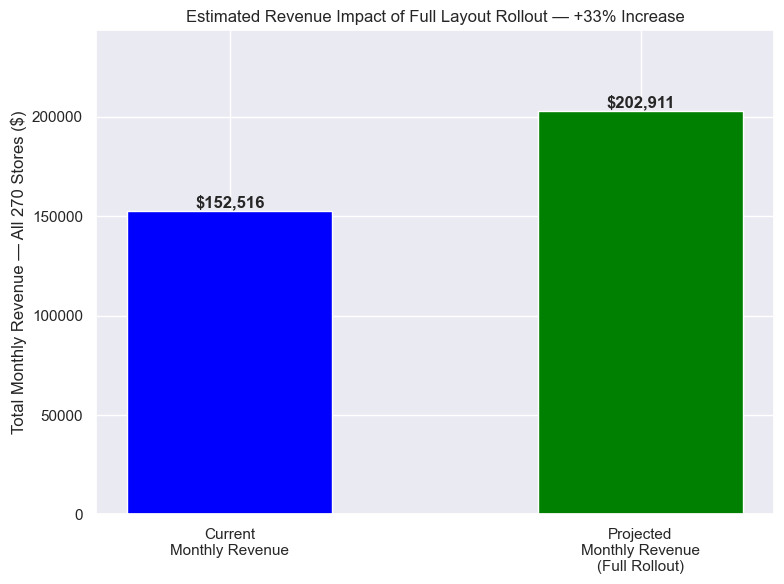

In [ ]:
projected_monthly = total_monthly_baseline + estimated_monthly_uplift

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    ['Current\nMonthly Revenue', 'Projected\nMonthly Revenue\n(Full Rollout)'],
    [total_monthly_baseline, projected_monthly],
    color=['blue', 'green'],
    width=0.5
)

for bar, value in zip(bars, [total_monthly_baseline, projected_monthly]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${value:,.0f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Total Monthly Revenue — All 270 Stores ($)')
ax.set_title(f'Estimated Revenue Impact of Full Layout Rollout — +{avg_uplift_77:.0%} Increase')
ax.set_ylim(0, projected_monthly * 1.2)
plt.tight_layout()
plt.show()

### Final Recommendation

The new store layout generated a statistically significant, sustained chip sales uplift in 1 of 3 trial stores (Store 77), a shorter-lived effect in Store 86, and no attributable effect in Store 88. Based on the average uplift observed in Store 77 across the three trial months — including an initial dip in February — a full rollout to all 270 stores is estimated to generate approximately $604,738 in incremental annual revenue** (a 33.% uplift on baseline monthly sales).

**Rollout priority:**
1. **Stores matching Store 77's profile** — traffic-driven uplift was statistically confirmed in March and April, following an initial adjustment period in February, with customer count reaching 67% above control by April. This is the only profile with a statistically defensible case for full rollout.
2. **Investigate Store 86 before expanding** — customer traffic was already elevated in February, but it took until March for that to translate into a statistically significant sales effect, and both faded back to normal by April. This suggests the layout can drive real traffic gains but may need supporting in-store activation or promotional programming to convert that traffic into sustained sales.
3. **Deprioritize stores matching Store 88's profile** — no layout-driven uplift was detected in sales or in either driver metric. Further investment is not recommended without a redesigned trial that better isolates the layout effect.

**For category management:** Regardless of layout rollout timing, shelf space and promotional priority should be reoriented toward Budget Older Families and Mainstream Young Singles/Couples — the two segments confirmed to drive the highest chip category revenue across the full store network.